In [29]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import json

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from google import genai

from IPython.display import display
import textwrap
def wrap(text, width=100):
    print('\n'.join(textwrap.wrap(text, width)))
    
import yaml

from pydantic import BaseModel, Field

from typing import Literal
from openai import OpenAI

import statsmodels.api as sm
import statsmodels.formula.api as smf

import sys
import os

sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../..'))

from apa_style import set_apa_style, get_figsize, format_axes_labels
set_apa_style()

import re

def to_float(value_str):
    # This regex finds digits and periods only
    # It removes $, oz, commas, etc.
    clean_str = re.sub(r'[^\d.]', '', value_str)
    try:
        value = float(clean_str)
    except:
        value = None
    return value

def get_price_weight(choice = 'coffee_a'):
    cues = config['cues']
    cs = [c for c in cues if c['option_id']==choice]
    if not cs:
        return None, None
    
    weight_oz = [c for c in cs if c['attribute_id']=='weight_oz'][0]['value']
    weight_oz = to_float(weight_oz)
    list_price = [c for c in cs if c['attribute_id']=='list_price'][0]['value']
    list_price = to_float(list_price)

    display_name = [c for c in config['options'] if c['id']==choice][0]['display_name']
    discount_percentage = to_float(display_name)
    if not discount_percentage: discount_percentage = 0
    sale_price = list_price - (list_price * discount_percentage/100)
    return sale_price, weight_oz

def calculate_effective_unit_cost(row):
    # Base facts about the options (5 bags)
    choice = row['choice']
    if not choice:
        return 
    
    price, weight = get_price_weight(choice)

    bags = 5
    total_price = price * bags
    total_oz = weight * bags
    
    # Extract agent's path
    num_clicks = row['num_tool_calls']
    cost_per_click = row['inspect_cell_tool_cost']
    total_search_cost = num_clicks * cost_per_click
    
    total_spent = total_price + total_search_cost
        
    # The DV: Effective Cost per Gram
    effective_unit_cost = total_spent / total_oz
    return effective_unit_cost

def load_events(results_file: str | Path) -> pd.DataFrame:
    """Load events.jsonl file into a single DataFrame."""
    path = Path(results_file)
    if results_file.stem[0]=='_':
        return
    frames = []
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line]
    if rows:
        frames.append(pd.DataFrame(rows))
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    return df

def load_all_events(results_files: list) -> pd.DataFrame:
    all_dfs = []
    for rf in results_files:
        temp_df = load_events(rf)
        all_dfs.append(temp_df)
    return pd.concat(all_dfs, ignore_index=True)


def _load_analysis_config(config: dict[str, Any] | str | Path | None) -> dict[str, Any] | None:
    if config is None or isinstance(config, dict):
        return config
    path = Path(config)
    text = path.read_text(encoding="utf-8")
    if path.suffix.lower() == ".json":
        return json.loads(text)
    return yaml.safe_load(text)


def get_data():
    results_files = list(results_dir.glob('*-events.jsonl'))
    config_files = list(results_dir.glob('*-config.json'))
    config_file = config_files[0] if config_files else None
    config = _load_analysis_config(config_file)
    metadata_columns = list(config['metadata'].keys())
    # print('metadata_columns', metadata_columns)

    df_raw = load_all_events(results_files)
    df = df_raw.copy().sort_values(['session_name', 'step_index'])
    meta_df = df['meta'].dropna().apply(pd.Series)
    meta_df = meta_df.add_prefix('meta_')
    if not meta_df.empty:
        df = df.join(meta_df)

    meta_cols = df.filter(like='meta_').columns
    df[meta_cols] = df.groupby('session_name')[meta_cols].ffill()
    return df, config

exp_name = 'study4-promotion-discountshown'

results_dir = Path('/home/dw/github/toollab/results/')/exp_name

df, config = get_data()
# print(f"{len(df)} events across {df['session_name'].nunique()} sessions")
# print(df[['option_count', 'design']])
print(df.columns)
print(df.shape)

all_attributes = [c['id'] for c in config['attributes']]

df = df.dropna(subset=['choice'])
df.groupby(['model_name', 'prompt_type','inspect_cell_tool_cost' ])['session_name'].nunique()

Index(['session_name', 'experiment_name', 'provider', 'model_name',
       'forced_choice', 'choice', 'budget_type', 'budget_max',
       'cumulative_cost_usd', 'budget_remaining_usd', 'cumulative_cost_tools',
       'budget_remaining_tools', 'cumulative_cost_tool_usd',
       'cumulative_cost_tokens', 'budget_remaining_tokens',
       'cumulative_cost_points', 'budget_remaining_points', 'option_count',
       'prompt_type', 'option_mapping', 'started_at', 'finished_at',
       'system_prompt', 'user_message', 'inspect_cell_tool_cost', 'step_index',
       'kind', 'content', 'reasoning', 'input_tokens', 'output_tokens',
       'input_cost', 'output_cost', 'tool_cost', 'point_cost', 'tool_usd_cost',
       'tool_calls', 'finish_reason', 'meta', 'tool_name', 'tool_call_id',
       'option_id', 'attribute_id', 'result', 'turn_cost_usd', 'is_revisit',
       'transition', 'most_important_attribute', 'confidence_score',
       'option_label', 'error', 'meta_thinking_level'],
      dtype='ob

model_name                     prompt_type     inspect_cell_tool_cost
gemini-3.1-flash-lite-preview  deal            0.0                       10
                                               0.5                       10
                                               1.0                       10
                                               2.0                       10
                                               5.0                       10
                                               10.0                       5
                               value_function  0.0                       10
                                               0.5                       10
                                               1.0                       10
                                               2.0                       10
                                               5.0                        9
Name: session_name, dtype: int64

In [36]:
df, config = get_data()

# df['is_optimal'] = (df['choice']=='coffee_b').astype(int)
def get_choice_discount(choice):
    if not choice:
        return np.nan
    
    display_name = [c for c in config['options'] if c['id']==choice][0]['display_name']
    discount_percentage = to_float(display_name)
    if not discount_percentage: discount_percentage = 0

    return discount_percentage

df['choice_discount'] = df['choice'].apply(get_choice_discount)
df['is_optimal'] = df['choice'].apply(lambda choice: choice=='coffee_e' if choice else None)

In [37]:
df.groupby('session_name').agg({
    'model_name':'first',
    'inspect_cell_tool_cost': 'first',
    'prompt_type': 'first',
    'choice': 'first',
}).groupby(['prompt_type','inspect_cell_tool_cost'])['choice'].value_counts()

prompt_type     inspect_cell_tool_cost  choice  
deal            0.0                     coffee_a    10
                0.5                     coffee_a    10
                1.0                     coffee_a    10
                2.0                     coffee_a    10
                5.0                     coffee_a     9
                                        coffee_e     1
                10.0                    coffee_a    10
value_function  0.0                     coffee_a    10
                0.5                     coffee_a    10
                1.0                     coffee_a    10
                2.0                     coffee_a    10
                5.0                     coffee_a     9
                                        coffee_b     1
                10.0                    coffee_a    10
Name: choice, dtype: int64

<Axes: xlabel='inspect_cell_tool_cost', ylabel='choice_discount'>

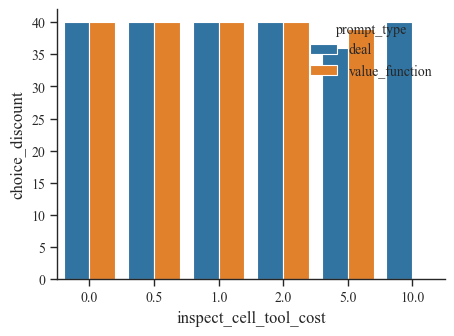

In [31]:
choice_discount = df.groupby(['session_name']).agg({
    'model_name': 'first',
    'inspect_cell_tool_cost': 'first',
    'prompt_type': 'first',
    'choice_discount': 'first',
    'is_optimal': 'first',
})
choice_discount_means = choice_discount.groupby(['model_name','prompt_type', 'inspect_cell_tool_cost'])['choice_discount'].mean()
# choice_discount['is_optimal'].value_counts(dropna=False)
sns.barplot(
    choice_discount_means.reset_index(),
    x = 'inspect_cell_tool_cost',
    y = 'choice_discount',
    hue='prompt_type',
    palette='tab10'
)

In [40]:
df_session_list = []
for session_name, session in df.groupby('session_name'):

    # display((session))
    inspect_cell_tool_cost = session['inspect_cell_tool_cost'].iloc[0]
    prompt_type = session['prompt_type'].iloc[0]
    model_name = session['model_name'].iloc[0]
    choice = session['choice'].iloc[0]
    choice_discount = session['choice_discount'].iloc[0]
    is_optimal = session['is_optimal'].iloc[0]

    subset_choice = session[session['tool_name']=='submit_choice']
    if subset_choice.empty:
        most_important_attribute = None    
    else:
        most_important_attribute = subset_choice['most_important_attribute'].iloc[0]

    # print(session.columns)
    subset_tools = session[session['tool_name']=='inspect_cell']
    # display(subset_tools.columns)
    tools_called = subset_tools['attribute_id'].unique().tolist()
    # print('tools_called', tools_called)
    has_discount = [tool for tool in tools_called if type(tool)==str and 'discount' in tool]
    # print('has_discount', any(has_discount))
    called_discount = int(any(has_discount))
    num_tool_calls = len(subset_tools)
    # print(tools_called)


    # --- Tool / Search Info ---
    subset_tools = session[session['tool_name'] == 'inspect_cell']
    
    # 1. Overall volume of search
    num_tool_calls = len(subset_tools)
    total_tool_cost_usd = session['cumulative_cost_tool_usd'].max() # Total money spent on tools
    
    # 2. Breadth of search (Options)
    options_inspected = subset_tools['option_id'].dropna().unique().tolist()
    # print(subset_tools['option_id'])
    num_options_inspected = len(options_inspected)
    
    # 3. Depth of search (Attributes)
    tools_called = subset_tools['attribute_id'].dropna().unique().tolist()
    
    # Specific attribute checks (Did they do the math or use a heuristic?)
    called_discount = int(any('discount' in str(tool) for tool in tools_called))
    called_weight = int('weight_oz' in tools_called)
    called_list_price = int('list_price' in tools_called)
    called_scarcity_cues = int(any(tool in ['promotion_deadline', 'stock_level'] for tool in tools_called))
    
    # Exhaustive math proxy: Did they check the 3 components needed to calculate true value?
    has_math_components = int(called_weight and called_list_price)

    # 4. Sequence / Stopping Rule (What triggered the choice?)
    if not subset_tools.empty:
        last_attribute_inspected = subset_tools['attribute_id'].iloc[-1]
        last_option_inspected = subset_tools['option_id'].iloc[-1]
        
        # Did they choose the item they were looking at right before stopping?
        chose_last_inspected = int(last_option_inspected == choice) 
    else:
        last_attribute_inspected = None
        last_option_inspected = None
        chose_last_inspected = 0
        
    # 5. Search efficiency
    num_revisits = subset_tools['is_revisit'].sum() if 'is_revisit' in subset_tools.columns else 0

    df_session_list.append({
        'session_name': session_name,
        'inspect_cell_tool_cost': inspect_cell_tool_cost,
        'prompt_type': prompt_type,
        'model_name': model_name,
        
        # Choice details
        'choice': choice,
        'choice_discount': choice_discount,
        'is_optimal': is_optimal,
        'most_important_attribute': most_important_attribute,
        
        # Search Truncation & Efficiency metrics
        'num_tool_calls': num_tool_calls,
        'total_tool_cost_usd': total_tool_cost_usd,
        'num_options_inspected': num_options_inspected,
        'num_revisits': num_revisits,
        
        # Heuristic vs Calculation metrics
        'tools_called': tools_called,
        'called_discount': called_discount, 
        'called_weight': called_weight,
        'called_list_price': called_list_price,
        'called_scarcity_cues': called_scarcity_cues,
        'has_math_components': has_math_components,
        
        # Mouselab Sequence/Stopping variables
        'last_attribute_inspected': last_attribute_inspected,
        'last_option_inspected': last_option_inspected,
        'chose_last_inspected': chose_last_inspected
    })
    
df_session = pd.DataFrame(df_session_list)
df_session['Effective_Cost_Per_oz'] = df_session.apply(calculate_effective_unit_cost, axis=1)
# df_session['Effective_Cost_Per_KG'] = df_session['Effective_Cost_Per_Gram']*1000

# # cap to 100 per cell
# df_session = df_session.groupby(
#     ['model_name', 'prompt_type', 'inspect_cell_tool_cost']
# ).head(100)

In [41]:
# df_session.groupby('model_name')['num_tool_calls'].value_counts()

<Axes: xlabel='inspect_cell_tool_cost', ylabel='pct_did_math'>

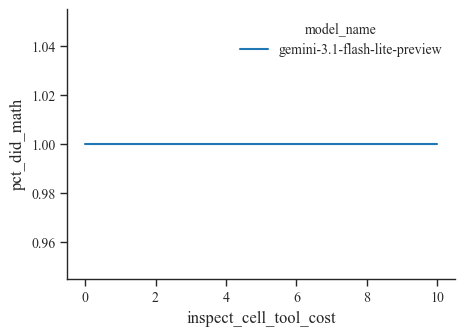

In [42]:
# 1. Quick look at the Main Effects and Truncation
summary_df = df_session.groupby(['model_name', 'prompt_type', 'inspect_cell_tool_cost']).agg(
    pct_optimal=('is_optimal', 'mean'),
    avg_choice_discount=('choice_discount', 'mean'), # Assuming you converted '40%' to 40
    avg_options_inspected=('num_options_inspected', 'mean'),
    pct_did_math=('has_math_components', 'mean'),
    avg_effective_cost=('Effective_Cost_Per_oz', 'mean')
).reset_index()

# Print to console
# display(summary_df)

# 2. Visualizing Truncation -> Heuristic Use
sns.lineplot(
    data=summary_df,
    x='inspect_cell_tool_cost',
    y='pct_did_math',
    hue='model_name',
    palette='tab10'
)


<Axes: xlabel='inspect_cell_tool_cost', ylabel='has_math_components'>

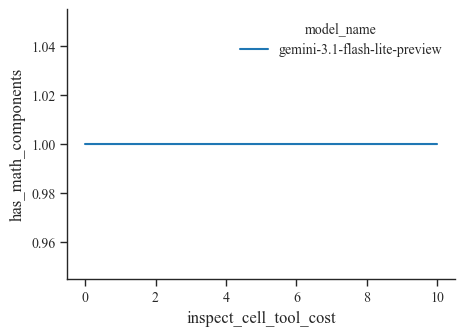

In [43]:
sns.lineplot(
    df_session,
    x = 'inspect_cell_tool_cost',
    y = 'has_math_components',
    hue='model_name',
    palette='tab10'
)

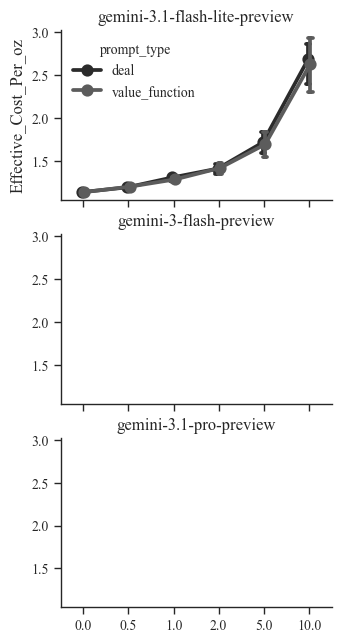

In [44]:
models = [
    'gemini-3.1-flash-lite-preview', 
    'gemini-3-flash-preview',
    'gemini-3.1-pro-preview',
]
prompt_types = df_session['prompt_type'].unique()
tool_costs = df_session['inspect_cell_tool_cost'].unique()

nrows = 3
ncols = 1

fig, axes = plt.subplots(len(models),1, figsize=get_figsize(nrows, ncols), sharex=True, sharey=True)
for model, ax in zip(models, axes):
    subset = df_session[df_session['model_name']==model]
    # display(subset)
    sns.pointplot(
        data=subset, 
        x='inspect_cell_tool_cost', 
        y='Effective_Cost_Per_oz', 
        hue='prompt_type',
        dodge=True,      # Slightly offsets the lines so they don't overlap perfectly
        capsize=.1,
        ax=ax
    )
    ax.set_title(model)
    # break

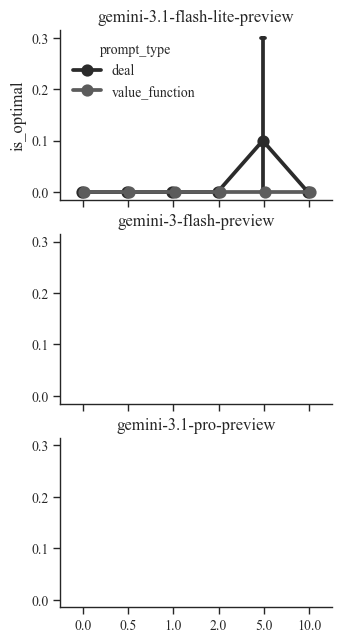

In [45]:
models = [
    'gemini-3.1-flash-lite-preview', 
    'gemini-3-flash-preview',
    'gemini-3.1-pro-preview',
]
prompt_types = df_session['prompt_type'].unique()
tool_costs = df_session['inspect_cell_tool_cost'].unique()

nrows = 3
ncols = 1

fig, axes = plt.subplots(len(models),1, figsize=get_figsize(nrows, ncols), sharex=True, sharey=True)
for model, ax in zip(models, axes):
    subset = df_session[df_session['model_name']==model]
    # display(subset)
    sns.pointplot(
        data=subset, 
        x='inspect_cell_tool_cost', 
        y='is_optimal', 
        hue='prompt_type',
        dodge=True,      # Slightly offsets the lines so they don't overlap perfectly
        capsize=.1,
        ax=ax
    )
    ax.set_title(model)
    # break

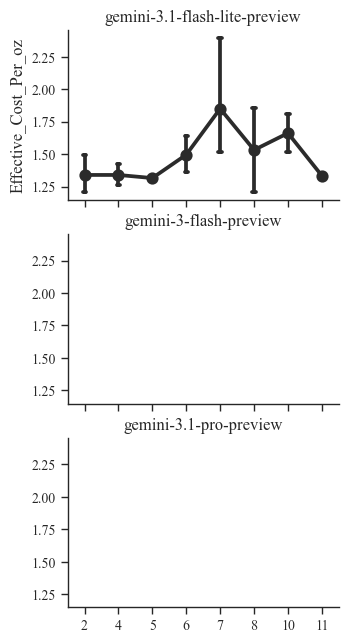

In [50]:
models = [
    'gemini-3.1-flash-lite-preview', 
    'gemini-3-flash-preview',
    'gemini-3.1-pro-preview',
]
prompt_types = df_session['prompt_type'].unique()
tool_costs = df_session['inspect_cell_tool_cost'].unique()

nrows = 3
ncols = 1

fig, axes = plt.subplots(len(models),1, figsize=get_figsize(nrows, ncols), sharex=True, sharey=True)
for model, ax in zip(models, axes):
    subset = df_session[df_session['model_name']==model]
    # display(subset)
    sns.pointplot(
        data=subset, 
        x='num_tool_calls', 
        y='Effective_Cost_Per_oz', 
        # hue='prompt_type',
        dodge=True,      # Slightly offsets the lines so they don't overlap perfectly
        capsize=.1,
        ax=ax
    )
    ax.set_title(model)
    # break

In [ ]:
plot_df = df_session.groupby(['model_name', 'inspect_cell_tool_cost'])['num_tool_calls'].mean().reset_index()
sns.lineplot(
    plot_df, 
    x = 'inspect_cell_tool_cost',
    y = 'num_tool_calls',
    hue = 'model_name',
)

In [145]:
all_attributes
for attribute in all_attributes:
    df_session[attribute] = df_session['tools_called'].apply(lambda l: int(attribute in l))

In [176]:
df_session.columns

Index(['session_name', 'inspect_cell_tool_cost', 'prompt_type', 'model_name',
       'choice', 'choice_discount', 'is_optimal', 'called_discount',
       'tools_called', 'num_tool_calls', 'most_important_attribute',
       'Effective_Cost_Per_oz', 'brand', 'is_discounted',
       'discount_percentage', 'promotion_deadline', 'stock_level',
       'roast_date', 'origin', 'packaging', 'calories', 'list_price',
       'weight_oz'],
      dtype='object')

<Axes: xlabel='inspect_cell_tool_cost', ylabel='discount_percentage'>

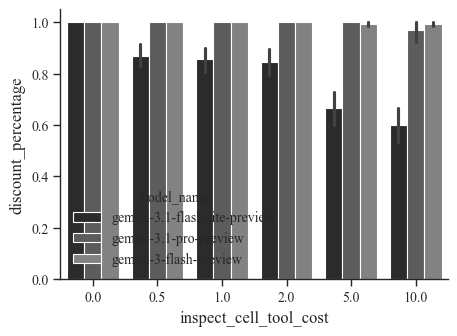

In [177]:
sns.barplot(
    df_session,
    x = 'inspect_cell_tool_cost',
    y = 'discount_percentage',
    hue = 'model_name',
)

<Axes: xlabel='inspect_cell_tool_cost', ylabel='list_price'>

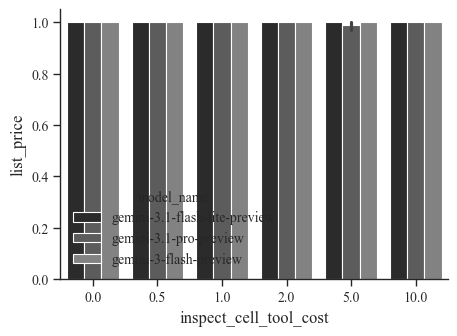

In [179]:
sns.barplot(
    df_session,
    x = 'inspect_cell_tool_cost',
    y = 'list_price',
    hue = 'model_name',
)

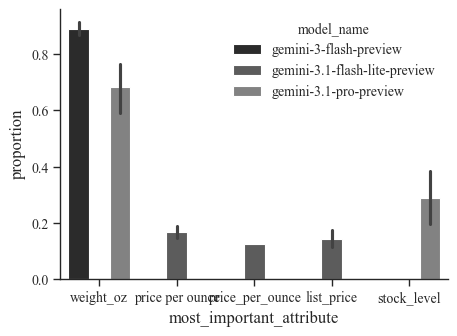

In [174]:
most_important_attribute_counts = df_session.groupby(['model_name', 'inspect_cell_tool_cost'])['most_important_attribute'].value_counts(normalize=True)
most_important_attribute_counts = most_important_attribute_counts[most_important_attribute_counts>0.1]
most_important_attribute_counts
ax = sns.barplot(
    most_important_attribute_counts.reset_index(name='proportion'),
    y = 'proportion',
    x = 'most_important_attribute',
    hue='model_name'
)


<Axes: xlabel='inspect_cell_tool_cost', ylabel='weight_oz'>

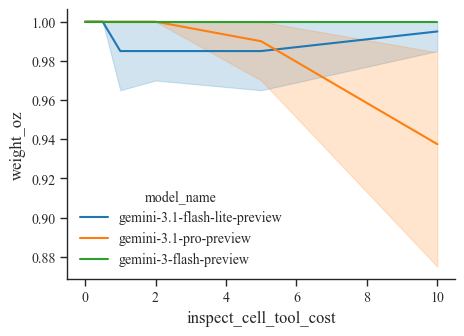

In [187]:
sns.lineplot(
    data=df_session,
    x = 'inspect_cell_tool_cost',
    y = 'weight_oz',
    hue = 'model_name',
    palette='tab10',
)

<Axes: xlabel='inspect_cell_tool_cost', ylabel='discount_percentage'>

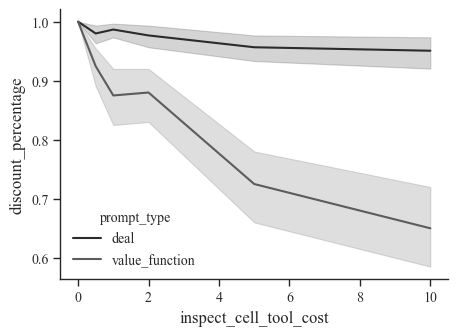

In [180]:
sns.lineplot(
    data=df_session,
    x = 'inspect_cell_tool_cost',
    y = 'discount_percentage',
    hue = 'prompt_type',
)

In [10]:
# Ensure your variables are formatted correctly
# We convert categorical variables into 'category' type so we can set references
df_session['prompt_type_cat'] = df_session['prompt_type'].astype('category')
df_session['model_name_cat'] = df_session['model_name'].astype('category')

# Set the reference levels as requested
df_session['prompt_type_cat'] = df_session['prompt_type_cat'].cat.reorder_categories(['deal', 'value_function'], ordered=False)
# Ensure your exact model string matches the one in your dataframe
df_session['model_name_cat'] = df_session['model_name_cat'].cat.reorder_categories(['gemini-3.1-flash-lite-preview', 'gemini-3-flash-preview', 'gemini-3.1-pro-preview'], ordered=False) 

# Formula: is_optimal is predicted by prompt_type, model_name, and cost
# C() tells the model these are Categorical variables
model = smf.logit(
    "is_optimal ~ C(prompt_type_cat) + C(model_name_cat) + inspect_cell_tool_cost", 
    data=df_session
).fit_regularized(method='l1', alpha=1.0) 

print(model.summary())


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.2141103854648062
            Iterations: 54
            Function evaluations: 55
            Gradient evaluations: 54
                           Logit Regression Results                           
Dep. Variable:             is_optimal   No. Observations:                  350
Model:                          Logit   Df Residuals:                      345
Method:                           MLE   Df Model:                            4
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.5174
Time:                        10:33:25   Log-Likelihood:                -63.880
converged:                       True   LL-Null:                       -132.36
Covariance Type:            nonrobust   LLR p-value:                 1.269e-28
                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


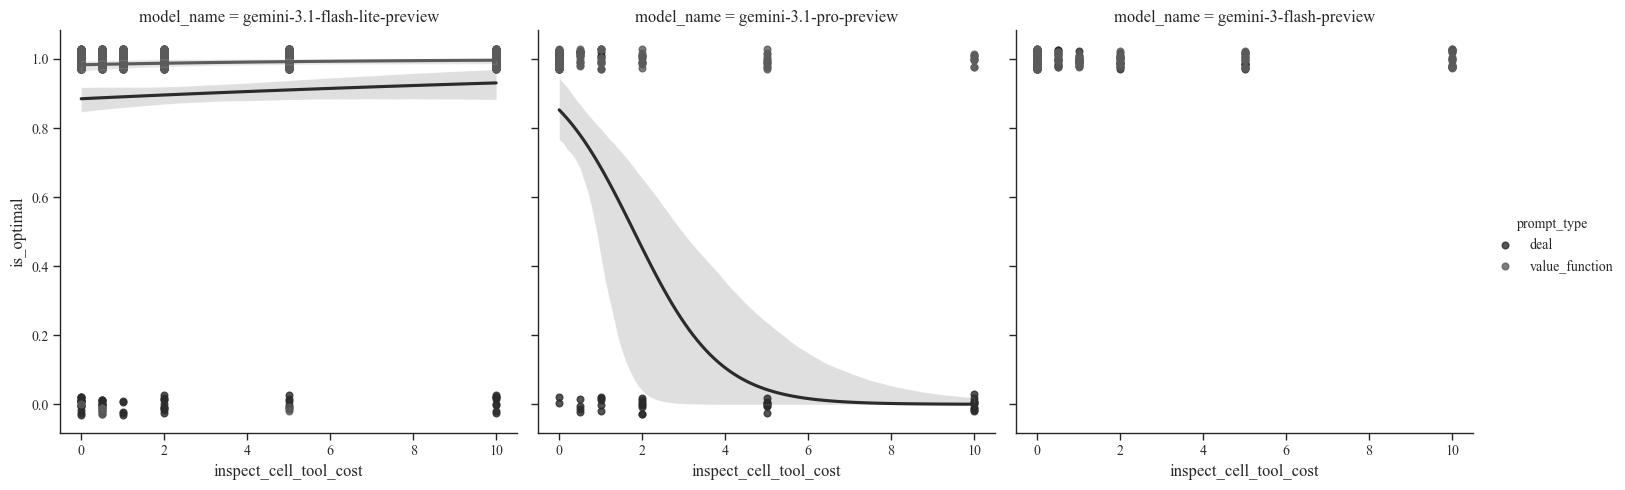

In [53]:
plot_df = df_session

sns.lmplot(
    data=plot_df, 
    x='inspect_cell_tool_cost', 
    y='is_optimal', 
    hue='prompt_type', 
    col='model_name',
    logistic=True, # This draws the S-curve of probability
    y_jitter=0.03,  # Makes the 0s and 1s easier to see
)

# the effect of constraint on choice

### max steps taken

<Axes: xlabel='model_name', ylabel='num_inspect'>

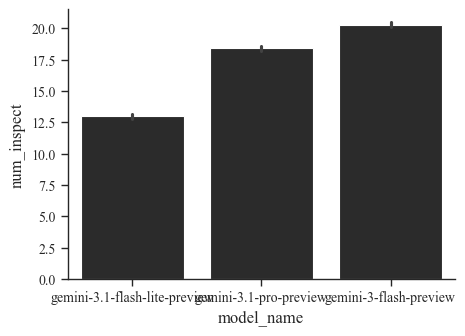

In [40]:
df, config = get_data()

df_copy = df.copy()
df_copy['is_inspect'] = df_copy['tool_name'] == 'inspect_cell'

num_inspect = df_copy.groupby('session_name').agg({
    'model_name':'first',
    'is_inspect': 'sum',
})
num_inspect = num_inspect.rename({'is_inspect':'num_inspect'}, axis=1)
# num_inspect.plot(kind='bar', x = 'budget_max', y='is_inspect')
sns.barplot(data=num_inspect, x = 'model_name', y = 'num_inspect')

#### Resource rational analysis

In [42]:
df, config = get_data()

inspect_cell_tool_cost = 10.0
gemini_pro = df[(df['model_name']=='gemini-3.1-pro-preview') & (df['inspect_cell_tool_cost']==inspect_cell_tool_cost)]
reasoning_traces = []
for index, (session_name, subset) in enumerate(gemini_pro.groupby('session_name')):
    print(index, session_name, subset['inspect_cell_tool_cost'].max())
    if (index+1)<len(gemini_pro.groupby('session_name')): continue
    assistant = subset[subset['kind']=='assistant']
    reasoning_trace_list = []
    for step, (i, row) in enumerate(assistant.iterrows(), 1):
        print(i)
        reasoning = row['reasoning']
        tc = subset.loc[i+1,['attribute_id', 'result', 'tool_name', 'cumulative_cost_tool_usd']]
        wrap(reasoning)
        reasoning_trace_list.append(f"Reasoning Step {step}:\n{reasoning.strip()}")
        reasoning_trace_list.append('-'*50)
        if tc['tool_name']=='inspect_cell':
            display(tc)
            reasoning_trace_list.append(f"Tool Response Step {step}:\n{tc.to_string().strip()}")
            reasoning_trace_list.append('-'*50)

        else:
            print()
            print(f"Choice: {row['choice']}, most_important_attribute: {subset.loc[i+1, 'most_important_attribute']}")
            reasoning_trace_list.append(f"Choice: {row['choice']}")

        # break
    full_trace = '\n\n'.join(reasoning_trace_list)
    reasoning_traces.append({
        'session_name': session_name,
        'full_trace': full_trace,
    })
    # display(assistant)
    # break
    print('+'*50)

0 20260422T044021679287Z 10.0
1 20260422T044209997387Z 10.0
2 20260422T044336327111Z 10.0
3 20260422T044441726621Z 10.0
4 20260422T044603995201Z 10.0
5 20260422T044729233621Z 10.0
6 20260422T044834447553Z 10.0
7 20260422T045015401459Z 10.0
8 20260422T045148284265Z 10.0
9 20260422T045333171434Z 10.0
10 20260422T045402400799Z 10.0
11 20260422T045521057826Z 10.0
12 20260422T045645014382Z 10.0
13 20260422T045802578987Z 10.0
14 20260422T045910483237Z 10.0
15 20260422T050027924390Z 10.0
16 20260422T050208824257Z 10.0
17 20260422T050326565206Z 10.0
18 20260422T050448262673Z 10.0
19 20260422T050601348662Z 10.0
20 20260422T050712454615Z 10.0
21 20260422T050816521849Z 10.0
22 20260422T050932013634Z 10.0
23 20260422T051048521799Z 10.0
24 20260422T051229681113Z 10.0
25 20260422T051404432706Z 10.0
26 20260422T051449276871Z 10.0
27 20260422T051602397070Z 10.0
28 20260422T051755326707Z 10.0
29 20260422T051925414909Z 10.0
30 20260422T052044579479Z 10.0
31 20260422T052153840493Z 10.0
32 20260422T052325

attribute_id                  list_price
result                            $12.60
tool_name                   inspect_cell
cumulative_cost_tool_usd            10.0
Name: 58755, dtype: object

58756
Okay, here's my interpretation of that thought process, from an expert's perspective:  **Price Point
Examination**  Alright, so we're looking at pricing, specifically a comparison between two options.
My initial data point is that Option 1 has a list price of $12.60. That gives me a baseline. Now,
the natural progression is to understand the corresponding metric for Option 2. This isn't a simple
case of "which is cheaper?". I'm going to leverage my expertise to understand where Option 2's
`list_price` fits into the overall landscape. I'm not making assumptions about its position relative
to Option 1 just yet. This initial scan is about setting a reference, and seeing if there's any
immediate deviation from the baseline before making any judgments. I need to delve into the data for
Option 2.


attribute_id                  list_price
result                            $14.00
tool_name                   inspect_cell
cumulative_cost_tool_usd            20.0
Name: 58757, dtype: object

58758
Okay, here's my take on those thoughts, framed as my own:  **Analyzing Pricing Data**  Alright, so
Option 2 is listed at $14.00. That's a data point. Now, let's pivot to Option 3. The immediate
question, of course, is what's the list price for that one? I need to quickly inspect the
`list_price` attribute associated with `option_3`. That's the baseline. Need to know the raw cost to
get a better context for comparisons.


...

58784
**Analyzing the Coffee Options**  Okay, so I'm looking at these coffee options. Option 5 is coming
in at 11.1 oz. Let's see... I've previously calculated that Option 1 provides 11.5 oz for $12.60,
which seems to be the most weight for that price point. However, before I make a final decision, I
need to make sure I am fully aware of everything that might affect the customer's purchase.  I need
to make sure I haven't missed any other key attributes like `promotion_deadline`, `stock_level`, or
even something like `calories`. The prompt is specifically mentioning that the user is buying *five*
bags of coffee.  That's it! Stock level! If the `stock_level` attribute for Option 1 is less than 5,
the customer simply *cannot* purchase their desired quantity. I need to verify what the stock level
is for that option before I suggest it. Let me check the `stock_level` attribute for option_1. This
will be the deciding factor.


attribute_id                 stock_level
result                          In Stock
tool_name                   inspect_cell
cumulative_cost_tool_usd           160.0
Name: 58785, dtype: object

58786
Okay, here's my interpretation of those thoughts, presented as a first-person expert summary:
**Assessing Inventory Availability**  Alright, I'm looking at this inventory status, and the first
option simply says "In Stock". That's a little…vague, isn't it? As an expert, I need more granular
data than that to make informed decisions about procurement or fulfillment. "In Stock" could mean
one unit or a thousand, and that makes a huge difference. Without a specific quantity, I can't
determine if this is sufficient for current demand or if I need to initiate a reorder. I'll need to
dig deeper for a precise number. Let's move on to the second option and see if it provides more
useful information.


attribute_id                 stock_level
result                      ONLY 3 LEFT!
tool_name                   inspect_cell
cumulative_cost_tool_usd           170.0
Name: 58787, dtype: object

58788
**Analyzing the Options for Maximum Value**  Okay, hold on a minute. "ONLY 3 LEFT!" on Option 2
immediately raises a red flag. If it were truly the best deal, I couldn't even fulfill the request
of purchasing 5 bags. Option 1, being "In Stock," is immediately more promising. And remember that
the user needs to purchase 5 bags of this product. I need to make sure that quantity is available.
Let's break this down systematically. Here's what I'm seeing based on the data:  *   **Option 1:**
$12.60 total, 11.5 oz, yielding $1.095/oz. Stock: In Stock. No discount, so no promotional deadline
to worry about. *   **Option 2:** (discounted) $14.00 * 0.9 = $12.60, 11.4 oz, $1.105/oz. Stock: 3
LEFT. *   **Option 3:** (discounted) $15.75 * 0.8 = $12.60, 11.3 oz, $1.115/oz. *   **Option 4:**
(discounted) $18.00 * 0.7 = $12.60, 11.2 oz, $1.125/oz. *   **Option 5:** (discounted) $21.00 * 0.6
= $12.60, 11.1 oz, $1.135/oz.  The crucial point here is that the final price after discount is the
same 

In [44]:
session_records = []
for session_name, subset in df.groupby('session_name'):
    # print(session_name)
    inspect_cell_tool_cost = subset['inspect_cell_tool_cost'].iloc[0]
    prompt_type = subset['prompt_type'].iloc[0]
    tool_call_subset = subset[subset['tool_name']=='inspect_cell']
    attributes_checked = set(tool_call_subset['attribute_id'].unique())
    num_check_cents = (tool_call_subset['attribute_id']=='price_cents').sum()
    checked_cents = int('price_cents' in tool_call_subset['attribute_id'].values)
    # print(num_check_cents)
    num_inspect = len(tool_call_subset)
    # print(num_inspect)
    # print(attributes_checked)


    submit_choice = subset[subset['tool_name']=='submit_choice']
    confidence_score = submit_choice['confidence_score'].iloc[0]
    final_choice = subset.choice.unique()[0]
    most_important_attribute = submit_choice['most_important_attribute'].iloc[0]
    
    tool_call_submit_choice = subset[subset['tool_calls'].str[0].str.get('name')=='submit_choice'].iloc[0]
    reasoning = tool_call_submit_choice['reasoning'] 
    # print('reasoning')
    # print(reasoning)

    phenotype = "Other / Irregular Search"

    distractors = {'brand', 'origin', 'packaging', 'calories', 'roast_date'}
    if len(attributes_checked.intersection(distractors))>0:
        phenotype = "5. Distracted/Ecological Search"
    # Phenotype 1: Classical Rational (Searched everything relevant)
    elif attributes_checked == {'price_dollars', 'price_cents', 'weight'}:
        if final_choice == 'coffee_b':
            phenotype = "1. Classical Rational (EV math, Over-searched)"
        elif final_choice == 'coffee_a':
            phenotype = "1b. Over-searched, Suboptimal Choice"
    
    # Phenotype: Pure Price Shopper (Ignored weight, calculated full price)
    elif attributes_checked == {'price_dollars', 'price_cents'}:
        phenotype = "2b. Pure Price Shopper (Ignored Weight)"
    # Phenotype 2: Lexicographic (Price ONLY)
    elif attributes_checked == {'price_dollars'}:
        phenotype = "2. Lexicographic (Dollars Only)"

    # Phenotypes 3 & 4: The Resource-Rational Target Group
    elif attributes_checked == {'price_dollars', 'weight'}:
        if final_choice == 'coffee_b':
            phenotype = "3. Resource-Rational (Skipped cents, EV Math)"
        elif final_choice == 'coffee_a':
            phenotype = "4. THE HOLY GRAIL (Skipped cents, Left-Digit Biased)"
    
    if phenotype == "Other / Irregular Search":
        print(attributes_checked)
    
    session_records.append({
        'session_name': session_name,
        'model_name': subset.iloc[0]['model_name'],
        'inspect_cell_tool_cost': inspect_cell_tool_cost,
        'prompt_type': prompt_type,
        'num_tool_calls': num_inspect,
        'num_check_cents':num_check_cents,
        'checked_cents':checked_cents,
        'attributes_checked': list(attributes_checked),
        'choice': final_choice,
        'phenotype': phenotype,
        'confidence_score': confidence_score,
        'most_important_attribute': most_important_attribute,
        'final_reasoning': reasoning
    })

    # display(submit_choice.T)
    # display(tool_call_subset)
session_df = pd.DataFrame(session_records)
# cap to 100 per cell
session_df = session_df.groupby(
    ['model_name', 'prompt_type', 'inspect_cell_tool_cost']
).head(100)

In [10]:
# session_df.groupby('phenotype')['most_important_attribute'].value_counts()
# session_df.groupby('model_name')['phenotype'].value_counts()

In [45]:
session_df['Effective_Cost_Per_Gram'] = session_df.apply(calculate_effective_unit_cost, axis=1)
session_df['Effective_Cost_Per_KG'] = session_df['Effective_Cost_Per_Gram']*1000

# print(session_df[['inspect_cell_tool_cost', "attributes_checked", 'num_tool_calls', 'final_choice','Effective_Cost_Per_Gram']].to_string())

<Axes: xlabel='model_name', ylabel='Effective_Cost_Per_KG'>

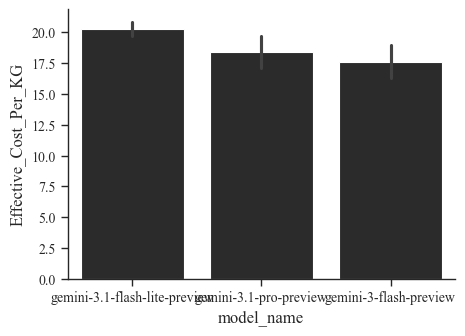

In [12]:
sns.barplot(
    session_df, 
    # x = 'num_tool_calls', 
    y = 'Effective_Cost_Per_KG', 
    # hue = 'inspect_cell_tool_cost',
    x = 'model_name'
)

In [13]:
session_df['Effective_Cost_Per_Gram'].describe()

session_df['prompt_type_cat'] = session_df['prompt_type'].astype('category')
session_df['model_name_cat'] = session_df['model_name'].astype('category')

# Set the reference levels as requested
session_df['prompt_type_cat'] = session_df['prompt_type_cat'].cat.reorder_categories(['deal', 'value_function'], ordered=False)
# Ensure your exact model string matches the one in your dataframe
# session_df['model_name_cat'] = session_df['model_name_cat'].cat.reorder_categories(['gemini-3.1-pro-preview', 'gemini-3-flash-preview','gemini-3.1-flash-lite-preview'], ordered=False) 
session_df['model_name_cat'] = session_df['model_name_cat'].cat.reorder_categories([
    'gemini-3.1-flash-lite-preview',
    'gemini-3-flash-preview',
    'gemini-3.1-pro-preview', 
], ordered=False) 


cost_model = smf.ols(
    "Effective_Cost_Per_KG ~ C(prompt_type_cat) * C(model_name_cat) + C(prompt_type_cat) * inspect_cell_tool_cost", 
    data=session_df
).fit()

print(cost_model.summary())

                              OLS Regression Results                             
Dep. Variable:     Effective_Cost_Per_KG   R-squared:                       0.915
Model:                               OLS   Adj. R-squared:                  0.915
Method:                    Least Squares   F-statistic:                     1842.
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                           12:23:03   Log-Likelihood:                -2768.1
No. Observations:                   1199   AIC:                             5552.
Df Residuals:                       1191   BIC:                             5593.
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

### Mediation analysis

Text(0, 0.5, 'Number of Tool Calls')

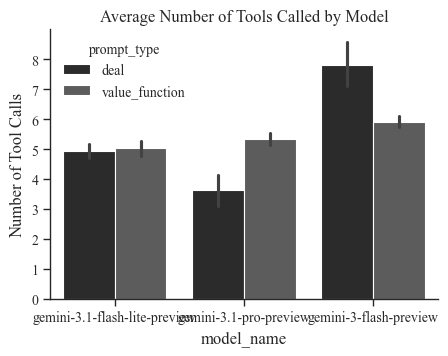

In [69]:
sns.barplot(
    data=session_df, 
    x='model_name', 
    y='num_tool_calls', 
    hue='prompt_type'
)
plt.title("Average Number of Tools Called by Model")
plt.ylabel("Number of Tool Calls")


Text(0, 0.5, '% of Time Price Cents Was Checked')

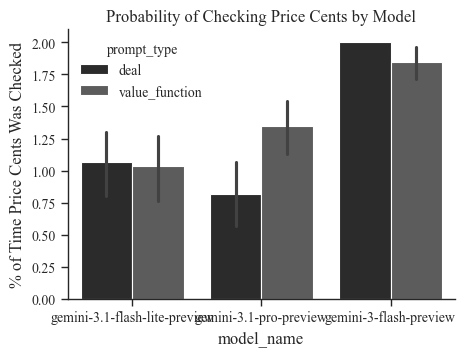

In [71]:
# Assuming 'checked_price_cents' is a boolean (True/False) or 0/1
sns.barplot(
    data=session_df, 
    x='model_name', 
    y='num_check_cents', # replace with your actual column name
    hue='prompt_type'
)
plt.title("Probability of Checking Price Cents by Model")
plt.ylabel("% of Time Price Cents Was Checked")


In [73]:
# Regression to explain the MECHANISM
mechanism_model = smf.ols(
    "Effective_Cost_Per_KG ~ C(prompt_type_cat) * C(model_name_cat) + num_tool_calls + num_check_cents", 
    data=session_df
).fit()

print(mechanism_model.summary())


                              OLS Regression Results                             
Dep. Variable:     Effective_Cost_Per_KG   R-squared:                       0.107
Model:                               OLS   Adj. R-squared:                  0.089
Method:                    Least Squares   F-statistic:                     5.970
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):           1.41e-06
Time:                           11:13:48   Log-Likelihood:                -1233.6
No. Observations:                    355   AIC:                             2483.
Df Residuals:                        347   BIC:                             2514.
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

Text(45.7361689814815, 0.5, 'Number of Tools Called')

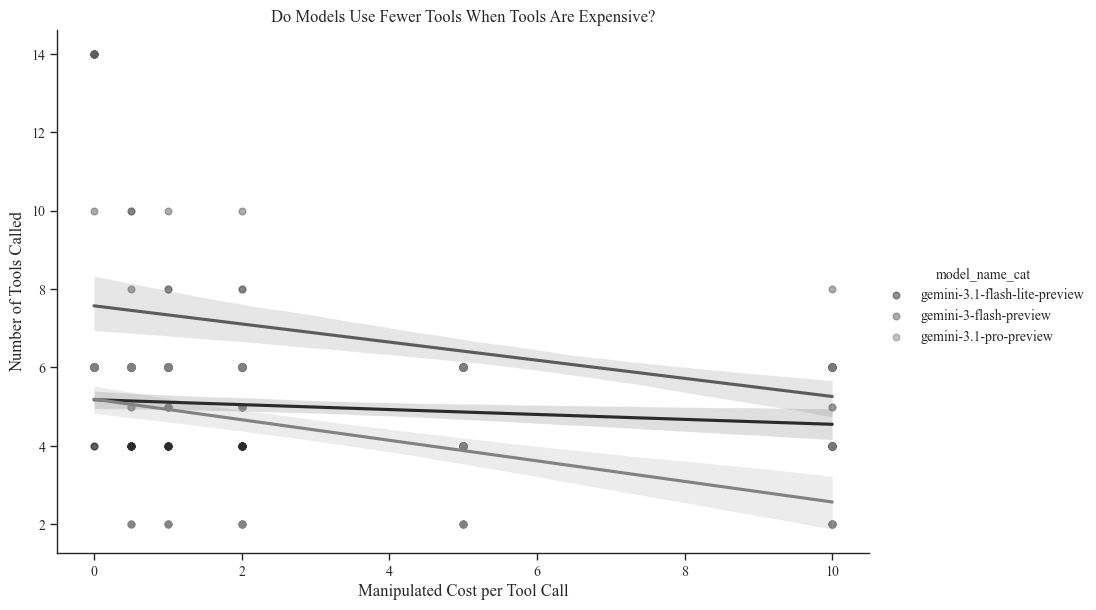

In [74]:
sns.lmplot(
    data=session_df,
    x='inspect_cell_tool_cost',
    y='num_tool_calls',
    hue='model_name_cat',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.5}
)
plt.title("Do Models Use Fewer Tools When Tools Are Expensive?")
plt.xlabel("Manipulated Cost per Tool Call")
plt.ylabel("Number of Tools Called")

In [75]:
# We are now predicting BEHAVIOR, not total cost.
behavior_model = smf.ols(
    "num_tool_calls ~ C(model_name_cat) * inspect_cell_tool_cost", 
    data=session_df
).fit()

print(behavior_model.summary())


                            OLS Regression Results                            
Dep. Variable:         num_tool_calls   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     39.10
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           7.51e-32
Time:                        11:21:22   Log-Likelihood:                -682.43
No. Observations:                 355   AIC:                             1377.
Df Residuals:                     349   BIC:                             1400.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

### Moderated mediation

In [106]:
# Assuming checked_price_cents is a 0/1 integer or boolean
heuristic_model = smf.ols(
    "num_check_cents ~ C(model_name_cat) * inspect_cell_tool_cost", 
    data=session_df
).fit()

print(heuristic_model.summary())


                            OLS Regression Results                            
Dep. Variable:        num_check_cents   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     32.72
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.37e-27
Time:                        11:47:36   Log-Likelihood:                -402.62
No. Observations:                 355   AIC:                             817.2
Df Residuals:                     349   BIC:                             840.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [109]:
terms = 'Effective_Cost_Per_KG ~ '
terms += 'C(model_name_cat) '
terms += '+ inspect_cell_tool_cost * num_tool_calls '
terms += '+ inspect_cell_tool_cost * C(checked_cents) '
# terms += '+ inspect_cell_tool_cost * num_check_cents'

rationality_model = smf.ols(
    terms, 
    data=session_df
).fit()

print(rationality_model.summary())


                              OLS Regression Results                             
Dep. Variable:     Effective_Cost_Per_KG   R-squared:                       0.992
Model:                               OLS   Adj. R-squared:                  0.992
Method:                    Least Squares   F-statistic:                     6418.
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                           11:48:43   Log-Likelihood:                -389.21
No. Observations:                    355   AIC:                             794.4
Df Residuals:                        347   BIC:                             825.4
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [112]:
full_mediation_model = smf.ols(
    "Effective_Cost_Per_KG ~ C(model_name_cat) * inspect_cell_tool_cost + num_tool_calls + C(checked_cents)", 
    data=session_df
).fit()

print(full_mediation_model.summary())


                              OLS Regression Results                             
Dep. Variable:     Effective_Cost_Per_KG   R-squared:                       0.953
Model:                               OLS   Adj. R-squared:                  0.952
Method:                    Least Squares   F-statistic:                     1014.
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):          1.02e-226
Time:                           11:50:07   Log-Likelihood:                -709.60
No. Observations:                    355   AIC:                             1435.
Df Residuals:                        347   BIC:                             1466.
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

In [111]:
session_df.corr(numeric_only=True)

,inspect_cell_tool_cost,num_tool_calls,num_check_cents,checked_cents,confidence_score,Effective_Cost_Per_Gram,Effective_Cost_Per_KG
inspect_cell_tool_cost,1.000000,-0.284985,-0.272264,-0.278309,-0.090332,0.946236,0.946236
num_tool_calls,-0.284985,1.000000,0.683455,0.668210,0.152251,-0.152766,-0.152766
num_check_cents,-0.272264,0.683455,1.000000,0.974299,0.252532,-0.074687,-0.074687
checked_cents,-0.278309,0.668210,0.974299,1.000000,0.259194,-0.082848,-0.082848
confidence_score,-0.090332,0.152251,0.252532,0.259194,1.000000,-0.038278,-0.038278
Effective_Cost_Per_Gram,0.946236,-0.152766,-0.074687,-0.082848,-0.038278,1.000000,1.000000
Effective_Cost_Per_KG,0.946236,-0.152766,-0.074687,-0.082848,-0.038278,1.000000,1.000000


### Process macro

In [14]:
session_df.model_name.unique()

array(['gemini-3.1-flash-lite-preview', 'gemini-3.1-pro-preview',
       'gemini-3-flash-preview'], dtype=object)

In [15]:
session_df_flashlite_pro = (session_df[session_df['model_name']!='gemini-3-flash-preview']).copy()
session_df_flashlite_pro.model_name.value_counts()

gemini-3.1-flash-lite-preview    894
gemini-3.1-pro-preview           120
Name: model_name, dtype: int64

In [19]:
import pandas as pd
from pyprocessmacro import Process

session_df_flashlite_pro['is_pro'] = (
    session_df_flashlite_pro['model_name'] == 'gemini-3.1-pro-preview'
).astype(int)

p = Process(
    data=session_df_flashlite_pro,
    model=8,
    x="inspect_cell_tool_cost",
    m=["num_tool_calls", "checked_cents"],
    y="Effective_Cost_Per_KG",
    w="is_pro",
    suppr_init=True,
    boot=10000
)

p.summary()


***************************** OUTCOME MODELS ****************************

Outcome = Effective_Cost_Per_KG 
OLS Regression Summary

     R²  Adj. R²    MSE         F  df1   df2  p-value
 0.9472   0.9469 3.5781 3619.5130    5  1008   0.0000

Coefficients

                                coeff     se        t      p    LLCI    ULCI
Cons                          11.5998 0.5932  19.5558 0.0000 10.4372 12.7624
inspect_cell_tool_cost         2.3326 0.0181 128.5490 0.0000  2.2971  2.3682
is_pro                        -0.2368 0.2574  -0.9201 0.3577 -0.7413  0.2676
inspect_cell_tool_cost*is_pro -0.2907 0.0534  -5.4393 0.0000 -0.3954 -0.1859
num_tool_calls                -0.3828 0.1483  -2.5808 0.0100 -0.6736 -0.0921
checked_cents                  4.0986 0.3292  12.4512 0.0000  3.4534  4.7438

-------------------------------------------------------------------------

Outcome = num_tool_calls 
OLS Regression Summary

     R²  Adj. R²    MSE       F  df1   df2  p-value
 0.1273   0.1238 1.0990 49.

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which

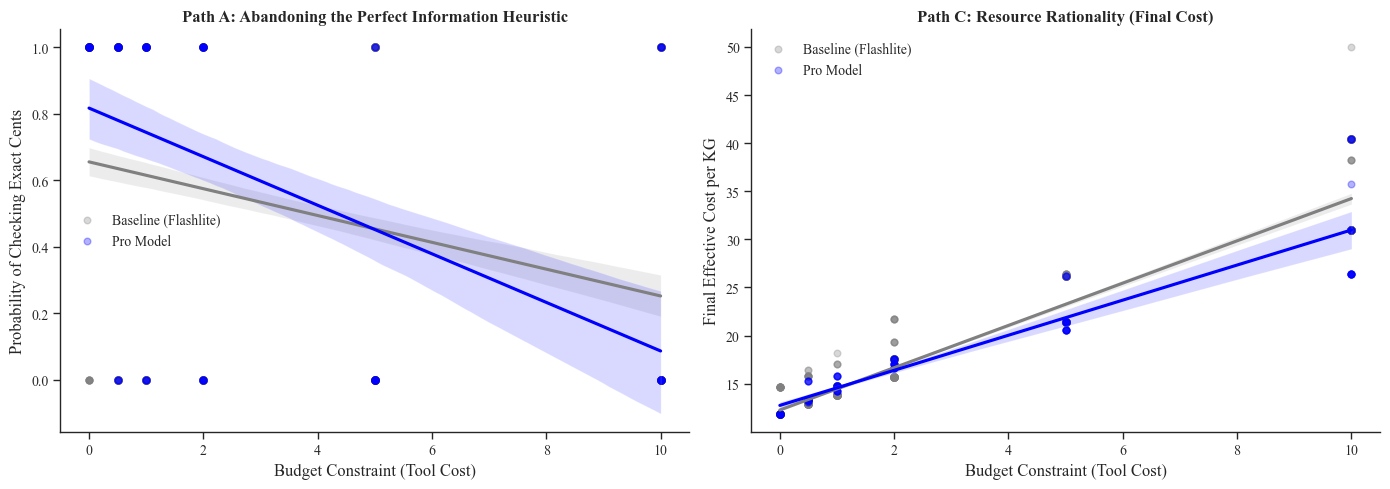

In [20]:
# Set academic style (clean, white background, no distracting grids)
# sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Create a figure with two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: The Heuristic (Checking Cents)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 0], 
    x='inspect_cell_tool_cost', y='checked_cents', 
    ax=axes[0], color='gray', label='Baseline (Flashlite)', scatter_kws={'alpha':0.3}
)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 1], 
    x='inspect_cell_tool_cost', y='checked_cents', 
    ax=axes[0], color='blue', label='Pro Model', scatter_kws={'alpha':0.3}
)
axes[0].set_title('Path A: Abandoning the Perfect Information Heuristic', fontweight='bold')
axes[0].set_xlabel('Budget Constraint (Tool Cost)')
axes[0].set_ylabel('Probability of Checking Exact Cents')
axes[0].legend()

# Plot B: The Final Outcome (Effective Cost)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 0], 
    x='inspect_cell_tool_cost', y='Effective_Cost_Per_KG', 
    ax=axes[1], color='gray', label='Baseline (Flashlite)', scatter_kws={'alpha':0.3}
)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 1], 
    x='inspect_cell_tool_cost', y='Effective_Cost_Per_KG', 
    ax=axes[1], color='blue', label='Pro Model', scatter_kws={'alpha':0.3}
)
axes[1].set_title('Path C: Resource Rationality (Final Cost)', fontweight='bold')
axes[1].set_xlabel('Budget Constraint (Tool Cost)')
axes[1].set_ylabel('Final Effective Cost per KG')
axes[1].legend()

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()


## Stat modelling

In [76]:
import statsmodels.formula.api as smf

model_name_to_size_dict = {
    'gemini-3.1-flash-lite-preview':'small',        
    'gemini-3-flash-preview':'medium',
    'gemini-3.1-pro-preview':'large',
}


In [77]:
# # 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
# search_proportions = pd.crosstab(
#     df['budget_max'], 
#     df['attribute_id'], 
#     normalize='index' # Converts counts to percentages (0.0 to 1.0)
# )

# # 2. Plot as a Stacked Bar Chart
# search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

# plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
# plt.xlabel('Max Budget (budget_max)', fontsize=12)
# plt.ylabel('Number of Total Searches', fontsize=12)
# plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

## Classify trace reasoning

In [139]:
from tool_lab.models.llamacpp_adapter import LlamaCppClient
class Config:
    model_name = 'gemma-4-31B-it-UD-Q4_K_XL.gguf'

attribute_list = [att['id'] for att in config['attributes']]

class AttributeClassification(BaseModel):
    label: Literal[*attribute_list]

def classify_choice_attribute(reasoning_text: str) -> str:
    if not reasoning_text: return 'No_Reasoning'
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    attribute_string = ''
    for att in attribute_list:
        attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are a highly precise data annotator analyzing the decision-making process of AI models. "
        "You will be provided with the reasoning an AI model gave for choosing a specific product. "
        "Your task is to identify the primary attribute that determined the model's final choice.\n\n"
        "Classify the reasoning into exactly one of these categories:\n"
        f'{attribute_string}'
    )
    
    user_prompt = reasoning_text

    try:
        response = client.chat.completions.parse(
            model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=AttributeClassification,
        )
        
        # Extract and clean up the classification result
        # print(response.choices[0])
        category = response.choices[0].message.parsed
        return category.label
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"


class TraceExtraction(BaseModel):
    # 1. Cost & Search Logic
    mentioned_tool_cost: bool = Field(
        description="Did the agent explicitly mention the numerical cost of using a tool (e.g., $2.00) in the text?"
    )
    performed_voi_calculation: bool = Field(
        description="Did the agent explicitly weigh the cost of searching against the potential monetary savings? (e.g., 'Checking this costs $3 but could save me $10')"
    )
    explicitly_skipped_cents: bool = Field(
        description="Did the agent explicitly state a reason for NOT checking the cents? (e.g., 'Cents won't make enough of a difference')."
    )

    # 2. Imputation of Missing Data (The Left-Digit Bias Check)
    cents_imputation_strategy: Literal["assumed_zero", "assumed_average", "acknowledged_missing_but_ignored", "not_mentioned"] = Field(
        description="How did the agent handle the missing cents when doing math? 'assumed_zero' means they treated the price as exactly $12.00 or $13.00. 'assumed_average' means they added ~0.50. 'acknowledged_missing' means they said 'we don't know the cents' but didn't assign a number."
    )

    # 3. Mathematical Evaluation
    calculated_value_ratio: bool = Field(
        description="Did the agent attempt to calculate a ratio of Price-to-Weight or Weight-to-Price? (e.g., '$0.92 per ounce' or '1.08 oz per dollar')"
    )
    math_hallucination: bool = Field(
        description="Based on the numbers the agent explicitly wrote down, was their final arithmetic incorrect?"
    )

    # 4. Tie-Breaking & Decision Rule
    primary_stated_decision_rule: Literal["best_value_ratio", "lowest_absolute_price", "highest_total_weight", "other"] = Field(
        description="What was the final stated reason for choosing the winning coffee?"
    )
    confidence_in_text: Literal["high", "moderate", "low"] = Field(
        description="Assess the tone of the final choice. 'high' means definitive ('clearly option A is better'). 'low' means uncertain ('I guess A might be better')."
    )


def classify_reasoning_trace(reasoning_text: str, provider='google') -> str:
    if not reasoning_text: return 'No_Reasoning'
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    # attribute_string = ''
    # for att in attribute_list:
    #     attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are an expert qualitative researcher analyzing the internal 'scratchpad' reasoning traces of an AI agent participating in an economic shopping simulation.\n"
        "The agent was choosing between Option A (approx $12, 13oz) and Option B (approx $13, 14.06oz) while paying to reveal hidden attributes.\n"
        "Read the provided reasoning trace carefully.\n" 
        "Your job is to extract the specific psychological and algorithmic behaviors the agent exhibited, strictly according to the provided JSON schema.\n"
        "Do not infer traits that are not explicitly written in the text or clearly demonstrated in the agent's written math."
    )
    
    try:
        if provider=='llamacpp':
            LlamaCppClient(Config())

            client = OpenAI(
                base_url='http://localhost:8080/v1',
                api_key="sk-no-key-required"
            )
            response = client.chat.completions.parse(
                model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": reasoning_text}
                ],
                response_format=TraceExtraction,
            )
            
            # Extract and clean up the classification result
            # print(response.choices[0])
            result = response.choices[0].message.parsed
        elif provider=='google':
            client = genai.Client()
            response = client.models.generate_content(
                model="gemini-3.1-flash-lite-preview",
                contents=reasoning_text,
                config={
                    "response_mime_type": "application/json",
                    "response_json_schema": TraceExtraction.model_json_schema(),
                    "system_instruction":system_prompt
                },
            )
            result = TraceExtraction.model_validate_json(response.text)

        return result
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"

In [127]:
trace_extraction = classify_reasoning_trace(reasoning_text=reasoning_traces[0])
trace_extraction

TraceExtraction(mentioned_tool_cost=True, performed_voi_calculation=True, explicitly_skipped_cents=False, cents_imputation_strategy='assumed_zero', calculated_value_ratio=True, math_hallucination=False, primary_stated_decision_rule='lowest_absolute_price', confidence_in_text='high')

In [142]:
for i, trace in enumerate(reasoning_traces):
    trace_extraction = classify_reasoning_trace(reasoning_text=trace['full_trace'])
    trace_extraction_dict = dict(trace_extraction)
    trace.update(trace_extraction_dict)
    # reasoning_traces[i] = dict(**trace, **trace_extraction_dict)


In [145]:
reasoning_traces

[{'session_name': '20260417T144433839636Z',
  'full_trace': 'Reasoning Step 1:\n**Coffee Purchase Decision**\n\nOkay, so I need to get ten bags of coffee. I have two options, let\'s call them option\\_1 and option\\_2. The problem is I don\'t have all the details at my fingertips. I *could* use `inspect_cell` to dig deeper, but each call costs fifty cents, which quickly adds up. I need to make a smart decision here. I need to figure out which option is going to give me the best deal on the beans.\n\nPrice is definitely key here. Since there\'s no stated preference, the price per bag is going to be my primary driver. I\'m thinking I\'ll need to look at `price_dollars` and `price_cents` for each option. The weight, `weight_oz`, will also matter as this would allow me to calculate price per ounce. Perhaps other attributes like `origin`, `brand`, or the `roast_date` might be relevant later, but, for now, I\'m focusing on the bottom line. So, let\'s start by checking those `price_dollars` a

# Rest

In [157]:
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'most_important_attribute':'first',
    'model_name': 'first'
})
most_important_attribute

,most_important_attribute,model_name
session_name,,
20260415T161414407849Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161429371264Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161443870482Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161520966406Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161604519148Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
...,...,...
20260415T232900107105Z,discount_percentage,gemini-3-flash-preview
20260415T232908851853Z,discount_percentage,gemini-3-flash-preview
20260416T011818303367Z,discount_percentage,gemini-3.1-pro-preview


In [158]:
reasoning_df = df[df['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

# 2. Your existing aggregation
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
sample = submit_choice_reasoning.iloc[0]
submit_choice_reasoning

,model_name,budget_max,most_important_attribute,reasoning
session_name,,,,
20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...
20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...
20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
...,...,...,...,...
20260415T232900107105Z,gemini-3-flash-preview,1,discount_percentage,**Decision Time: Limited Information and Budge...
20260415T232908851853Z,gemini-3-flash-preview,1,discount_percentage,"**My Decision: Option 1**\n\nOkay, here's the ..."
20260416T011818303367Z,gemini-3.1-pro-preview,20,discount_percentage,"**My Decision-Making Process**\n\nOkay, so I'm..."


In [159]:
submit_choice_reasoning.isna().sum()

model_name                  0
budget_max                  0
most_important_attribute    0
reasoning                   2
dtype: int64

In [ ]:
# submit_choice_reasoning['predicted_attribute'] = None
for i, row in submit_choice_reasoning.iterrows():
    predicted_attribute = classify_choice_attribute(row['reasoning'])
    submit_choice_reasoning.at[i, 'predicted_attribute'] = predicted_attribute
    print(row['model_name'], row['budget_max'], predicted_attribute, 'vs.', row['most_important_attribute'])

In [61]:
# submit_choice_reasoning.to_csv(results_dir/'predicted_attributes.csv')


In [93]:
submit_choice_reasoning = pd.read_csv(results_dir/'predicted_attributes.csv')
submit_choice_reasoning

,session_name,model_name,budget_max,most_important_attribute,reasoning,predicted_attribute
0,20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...,weight_oz
1,20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
2,20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...,discount_percentage
3,20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
4,20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
...,...,...,...,...,...,...
235,20260415T211739771084Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,discount_percentage,Option_3 is not discounted. So if we're lookin...,discount_percentage
236,20260415T211835575838Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,Both option_1 and option_3 were roasted 2 week...,weight_oz
237,20260415T211933959232Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option_2 has only 3 left in stock, but it's st...",weight_oz
238,20260415T212023423393Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option 1: $12.60 (no discount), 11.5 oz\nPrice...",weight_oz


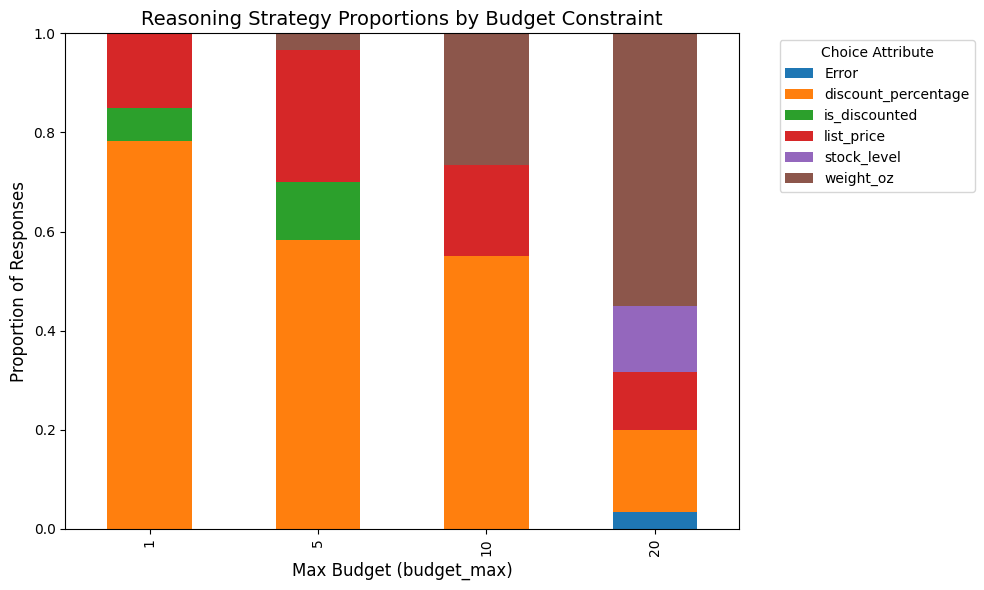

In [76]:
# 1. Create a cross-tabulation and normalize it so each row sums to 1.0 (100%)
crosstab_pred = pd.crosstab(
    submit_choice_reasoning['budget_max'], 
    submit_choice_reasoning['predicted_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_pred.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

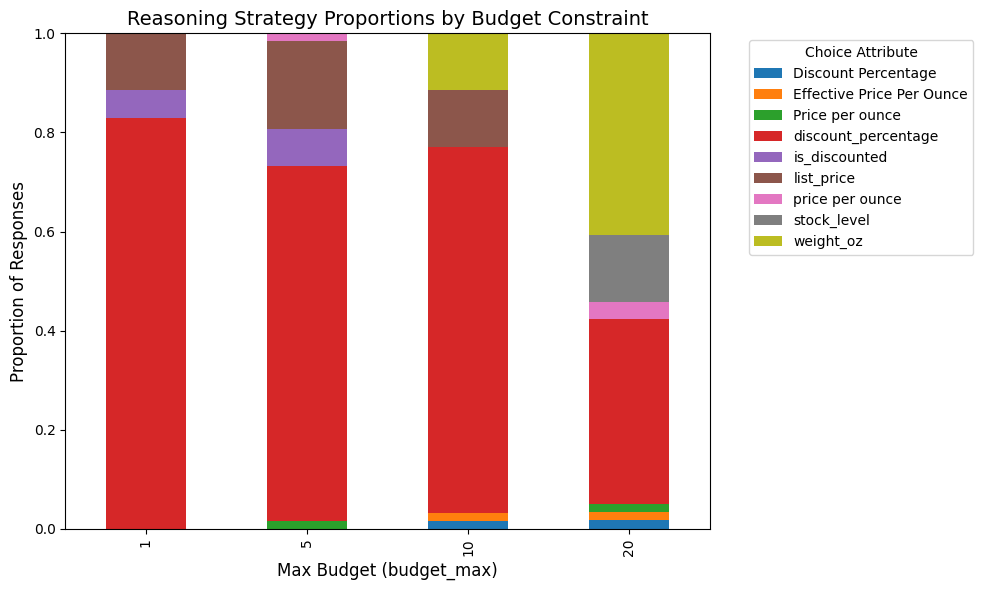

In [144]:
claimed_counts = submit_choice_reasoning['most_important_attribute'].value_counts()
top_claims = claimed_counts[claimed_counts>1].index
top_claims_df = submit_choice_reasoning[submit_choice_reasoning['most_important_attribute'].isin(top_claims)]
top_claims_df['most_important_attribute'].value_counts()

crosstab_claimed = pd.crosstab(
    top_claims_df['budget_max'], 
    top_claims_df['most_important_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_claimed.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [102]:
submit_choice_reasoning['model_name'].unique()

<StringArray>
['gemma-4-31B-it-UD-Q4_K_XL.gguf',    'Qwen3.5-27B-UD-Q4_K_XL.gguf',
     'Qwen3.5-9B-UD-Q4_K_XL.gguf',     'Qwen3.5-4B-UD-Q4_K_XL.gguf',
 'gemma-4-E4B-it-UD-Q4_K_XL.gguf', 'gemma-4-E2B-it-UD-Q4_K_XL.gguf']
Length: 6, dtype: str

In [109]:
# submit_choice_reasoning['num_params']
model_name_to_billion_dict = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 31,    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 27,
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 9,     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 4,
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 4, 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 2,
}
model_name_to_family = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 'gemma',    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 'qwen',
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 'qwen',     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 'qwen',
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 'gemma', 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 'gemma',
}


In [115]:
import statsmodels.formula.api as smf

# Convert the boolean column to integer (0 or 1) for the model
submit_choice_reasoning['discount_target'] = (submit_choice_reasoning['predicted_attribute']=='discount_percentage').astype(int)
submit_choice_reasoning['num_params'] = submit_choice_reasoning['model_name'].map(model_name_to_billion_dict)
submit_choice_reasoning['model_family'] = submit_choice_reasoning['model_name'].map(model_name_to_family)

# Fit the logistic regression model
# This tests if continuous 'budget_max' predicts the binary 'discount_target'
logit_model = smf.logit('discount_target ~ budget_max + num_params * model_family', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.589494
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        discount_target   No. Observations:                  240
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            4
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1485
Time:                        15:50:16   Log-Likelihood:                -141.48
converged:                       True   LL-Null:                       -166.15
Covariance Type:            nonrobust   LLR p-value:                 4.967e-10
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           1.2876      0.335      3.844  

### Attributes checked

In [105]:
df, config = get_data(exp_name)
df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

model_name                      budget_max
Qwen3.5-27B-UD-Q4_K_XL.gguf     1             10
                                4             10
                                6             10
                                16            10
Qwen3.5-4B-UD-Q4_K_XL.gguf      1             10
                                4             10
                                6             10
                                16            10
Qwen3.5-9B-UD-Q4_K_XL.gguf      1             10
                                4             10
                                6             10
                                16            10
gemini-3-flash-preview          1             10
                                4             10
                                6             10
                                16            10
gemini-3.1-flash-lite-preview   1             10
                                4             10
                                6             10
                          

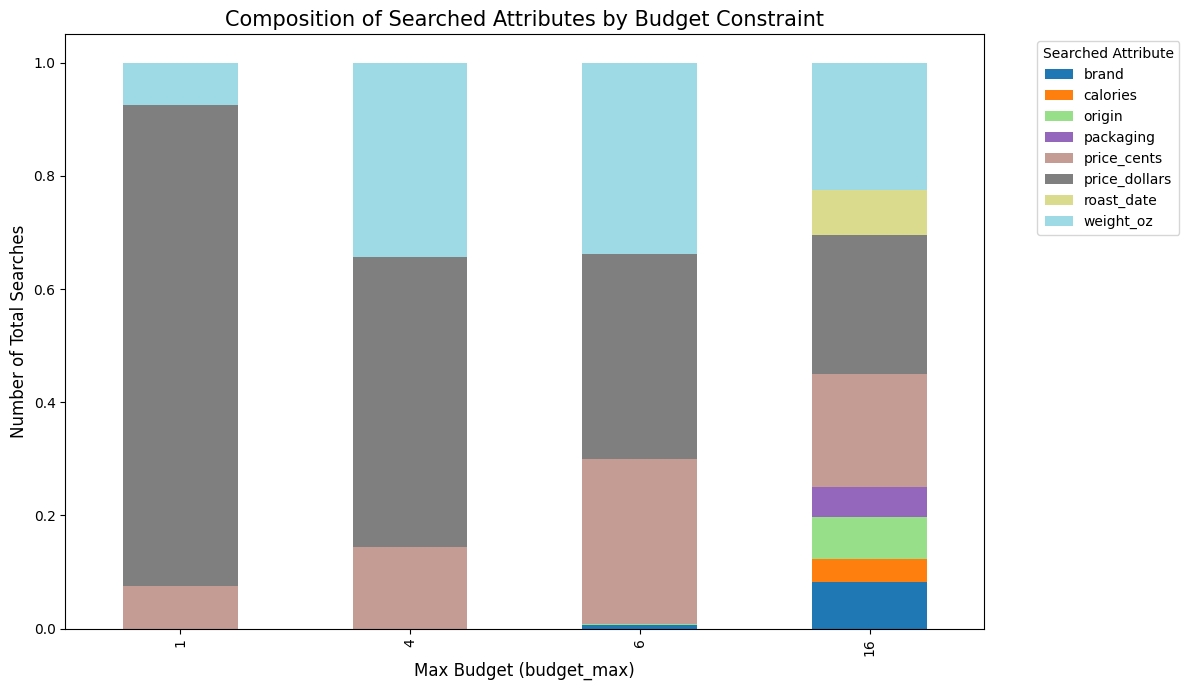

In [106]:
# 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
search_proportions = pd.crosstab(
    df['budget_max'], 
    df['attribute_id'], 
    normalize='index' # Converts counts to percentages (0.0 to 1.0)
)

# 2. Plot as a Stacked Bar Chart
search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Number of Total Searches', fontsize=12)
plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

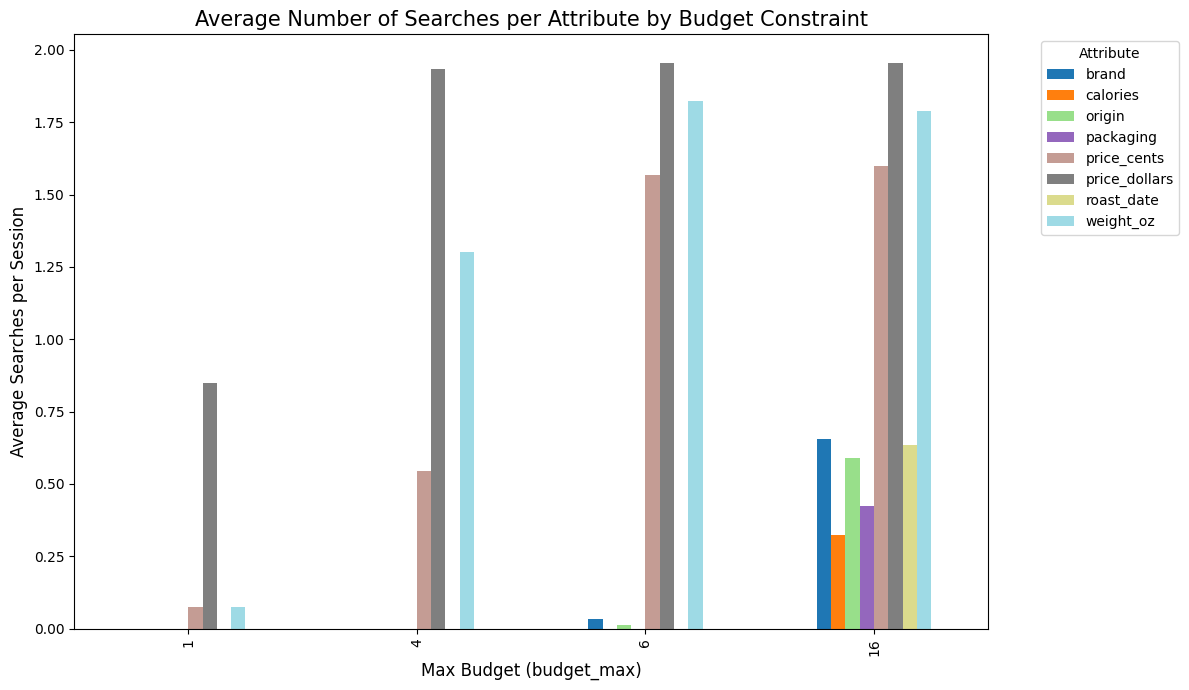

In [107]:
df_summary = (
    df.groupby(['session_name', 'budget_max'])['attribute_id']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
# 1. Using the df_summary from the previous step:
# Drop 'session_name' so we only have numbers, then group by budget and get the mean
mean_searches_per_budget = df_summary.drop(columns=['session_name']).groupby('budget_max').mean()
mean_searches_per_budget

# 2. Plot as a grouped bar chart (not stacked)
mean_searches_per_budget.plot(kind='bar', figsize=(12, 7), colormap='tab20')

plt.title('Average Number of Searches per Attribute by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Average Searches per Session', fontsize=12)
plt.legend(title='Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### most_important_attribute

In [108]:
df, config = get_data(exp_name)
# (df[df['budget_max']==20]).groupby('model_name')['choice'].value_counts(dropna=False)
if df.choice.isna().sum():
    print(f'we have missing choices: {df.choice.isna().sum()}')
# df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

we have missing choices: 4


In [109]:
df_submit_choice = (df[(df['kind']=='tool')&(df['tool_name']=='submit_choice')]).copy()
df_submit_choice_summary = (
    df_submit_choice.groupby(['budget_max'])['most_important_attribute']
    .value_counts(normalize=True)
    # .unstack(fill_value=0)
    .reset_index()
)

([0, 1, 2, 3],
 [Text(0, 0, '1'), Text(1, 0, '4'), Text(2, 0, '6'), Text(3, 0, '16')])

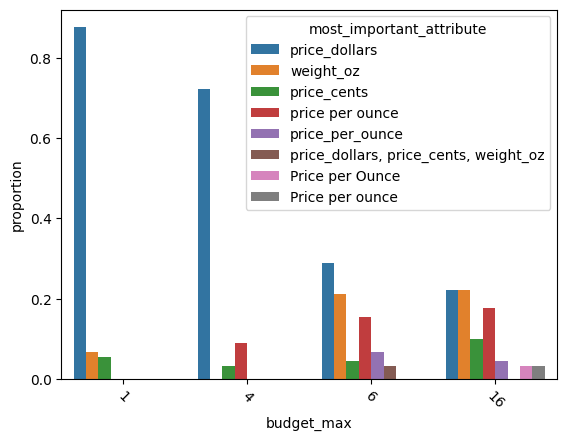

In [110]:
df_summary_count_g1 = df_submit_choice_summary[df_submit_choice_summary['proportion']>0.03]
ax = sns.barplot(data = df_summary_count_g1, hue = 'most_important_attribute', y = 'proportion', x='budget_max')
plt.xticks(rotation=-45)

In [ ]:
df_copy = df.copy()
df_copy['is_inspect'] = df_copy['tool_name'] == 'inspect_cell'


reasoning_df = df_copy[df_copy['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

num_inspect = df_copy.groupby(['session_name']).agg({
    'is_inspect': 'sum',
}).rename({'is_inspect':'num_inspect'}, axis=1)
num_inspect['num_inspect'].value_counts()

# 2. Your existing aggregation
most_important_attribute = (df_copy[df_copy['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
    'choice':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
submit_choice_reasoning = submit_choice_reasoning.join(num_inspect)

price_stats = df_copy.groupby('session_name')['attribute_id'].agg(
    has_price_cents = lambda x: (x == 'price_cents').any().astype(int),
    count_price_cents = lambda x: (x == 'price_cents').sum()
)

# 2. Join to your existing summary dataframe
submit_choice_reasoning = submit_choice_reasoning.join(price_stats)

total_attributes = 8
num_options = 2
total_cells = total_attributes * num_options
submit_choice_reasoning['constraint'] = 1 - (submit_choice_reasoning['budget_max']/total_cells)
TOTAL_PRICE_CENTS = 2
submit_choice_reasoning['ignored_price_cents'] = TOTAL_PRICE_CENTS - submit_choice_reasoning['count_price_cents']

submit_choice_reasoning['ignored_cents_bool'] = 1 - submit_choice_reasoning['has_price_cents']

submit_choice_reasoning['oz_per_price'] = submit_choice_reasoning['choice'].apply(lambda choice: [opt['base_score'] for opt in config['options'] if opt['id']==choice][0])


# submit_choice_reasoning.groupby(['model_name','budget_max']).count()
# submit_choice_reasoning

In [115]:
import statsmodels.formula.api as smf

# Fit the logistic regression model
logit_model = smf.ols('ignored_price_cents ~ constraint', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

                             OLS Regression Results                            
Dep. Variable:     ignored_price_cents   R-squared:                       0.285
Model:                             OLS   Adj. R-squared:                  0.283
Method:                  Least Squares   F-statistic:                     142.3
Date:                 Thu, 16 Apr 2026   Prob (F-statistic):           7.78e-28
Time:                         11:09:22   Log-Likelihood:                -441.99
No. Observations:                  359   AIC:                             888.0
Df Residuals:                      357   BIC:                             895.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1974      0.084      2.34

(0.9, 1.1224499999999997)

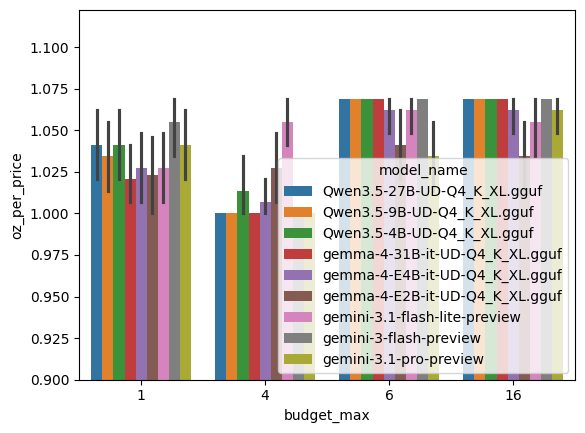

In [140]:
sns.barplot(submit_choice_reasoning, x = 'budget_max', y = 'oz_per_price', hue='model_name')
plt.ylim(0.9)

In [144]:
submit_choice_reasoning.groupby(['budget_max', 'model_name'])['choice'].value_counts()

budget_max  model_name                      choice  
1           Qwen3.5-27B-UD-Q4_K_XL.gguf     coffee_b     6
                                            coffee_a     4
            Qwen3.5-4B-UD-Q4_K_XL.gguf      coffee_b     6
                                            coffee_a     4
            Qwen3.5-9B-UD-Q4_K_XL.gguf      coffee_a     5
                                            coffee_b     5
            gemini-3-flash-preview          coffee_b     8
                                            coffee_a     2
            gemini-3.1-flash-lite-preview   coffee_a     6
                                            coffee_b     4
            gemini-3.1-pro-preview          coffee_b     6
                                            coffee_a     4
            gemma-4-31B-it-UD-Q4_K_XL.gguf  coffee_a     7
                                            coffee_b     3
            gemma-4-E2B-it-UD-Q4_K_XL.gguf  coffee_a     6
                                            coffee_b     3
   